In [ ]:
import pandas as pd
#Extra Imports
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# A problem occured, no time to fix 
# import geopandas as gpd


In [234]:
df = pd.read_csv("cleaned_crime_data.csv")

## Data Overview

In [235]:

df.head()

,Crime ID,Year,Month,Reported by,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,District,Outcome type,Population
0,48c1007edc34d286b599720b7518058e9f75e6928ca2dc...,2024,January,Devon & Cornwall Police,-1.961000,50.745104,On or near Calder Road,E01015411,"Bournemouth, Christchurch and Poole 016E",Other theft,"Bournemouth, Christchurch and Poole",Unable to prosecute suspect,1319
1,4d913f4f5875e7b7726bb10f1633fdc5d3a47edd16ea5d...,2024,January,Devon & Cornwall Police,-0.758195,51.397477,On or near Fitzroy Close,E01016231,Bracknell Forest 010D,Vehicle crime,Bracknell Forest,Investigation complete; no suspect identified,1975
2,9ac9fcc7d22103973f626a69ae4c9fefd54151d5addc1e...,2024,January,Devon & Cornwall Police,-2.599344,51.450094,On or near Nightclub,E01033909,Bristol 061C,Theft from the person,Bristol,Action to be taken by another organisation,2321
3,e3a99af51ec4babcb0680c0f027b7254d80ba8f168adbd...,2024,January,Devon & Cornwall Police,-1.933391,52.751848,On or near Hilltop,E01029346,Cannock Chase 003B,Violence and sexual offences,Cannock Chase,Unknown,1791
4,abe881ef6ba45b35a8e1ba5b4d5de25b9140413743c286...,2024,January,Devon & Cornwall Police,-1.933391,52.751848,On or near Hilltop,E01029346,Cannock Chase 003B,Violence and sexual offences,Cannock Chase,Unknown,1791


In [7]:
print("Number of columns:", df.shape[1])
print("Number of rows:", df.shape[0])


Number of columns: 23
Number of rows: 3337712


In [236]:
# checking columns
list(df.columns)

['Crime ID',
 'Year',
 'Month',
 'Reported by',
 'Longitude',
 'Latitude',
 'Location',
 'LSOA code',
 'LSOA name',
 'Crime type',
 'District',
 'Outcome type',
 'Population']

## Crime Distribution 

In [ ]:
# counts of different crimes total 
crimetype_counts = df["Crime type"].value_counts()
crimetype_counts

Crime type
Violence and sexual offences    1025793
Anti-social behaviour            362167
Other theft                      295421
Shoplifting                      290843
Vehicle crime                    270137
Criminal damage and arson        210085
Theft from the person            201477
Public order                     183650
Burglary                         158246
Drugs                            133627
Robbery                           86956
Other crime                       50014
Bicycle theft                     38200
Possession of weapons             31096
Name: count, dtype: int64

In [237]:
# top 3 crimes
crimetype_counts.head(3)

Crime type
Violence and sexual offences    1025793
Anti-social behaviour            362167
Other theft                      295421
Name: count, dtype: int64

In [238]:
# % of totals
(df["Crime type"].value_counts(normalize=True) * 100).round(2)

Crime type
Violence and sexual offences    30.73
Anti-social behaviour           10.85
Other theft                      8.85
Shoplifting                      8.71
Vehicle crime                    8.09
Criminal damage and arson        6.29
Theft from the person            6.04
Public order                     5.50
Burglary                         4.74
Drugs                            4.00
Robbery                          2.61
Other crime                      1.50
Bicycle theft                    1.14
Possession of weapons            0.93
Name: proportion, dtype: float64

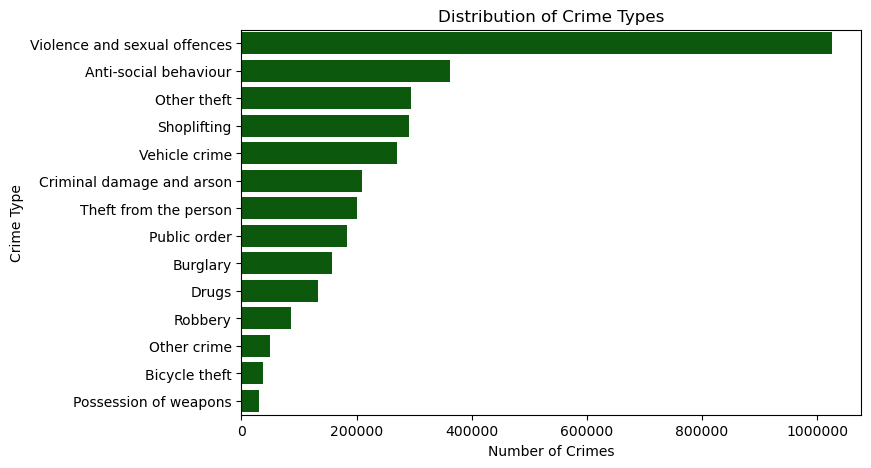

In [283]:
# plotting bar chart

plt.figure(figsize=(8,5))
sns.barplot(x=crimetype_counts, y=crimetype_counts.index, color="darkgreen")

plt.title("Distribution of Crime Types")

plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")

# to change the format of the x axis
plt.ticklabel_format(style='plain', axis='x')

plt.show()

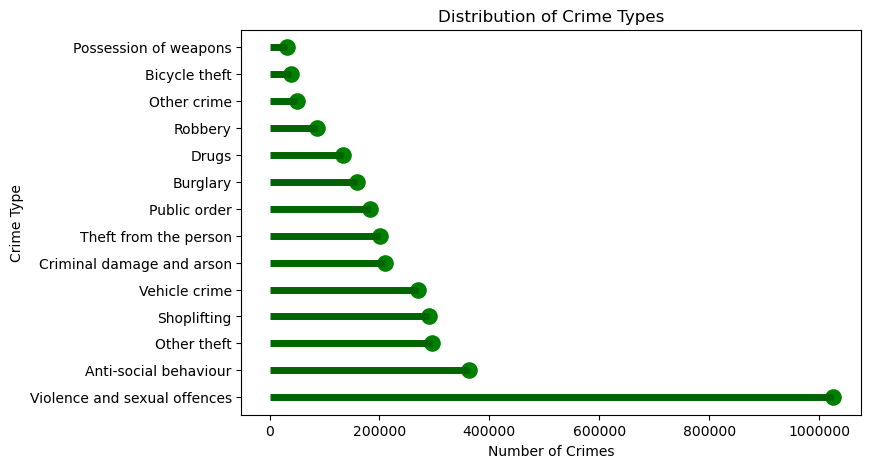

In [380]:
plt.figure(figsize=(8,5))

plt.hlines(y=crimetype_counts.index, xmin=0, xmax=crimetype_counts, color="darkgreen", linewidth = 5)

plt.scatter(crimetype_counts, crimetype_counts.index, color="green", s=120)

plt.title("Distribution of Crime Types")
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")

# to make the x axis display the correct values
plt.ticklabel_format(style='plain', axis='x')

plt.show()

## Comparison between police forces


In [ ]:
df["Reported by"].value_counts()

Reported by_crime
Metropolitan Police Service    2223054
West Midlands Police            708277
Devon & Cornwall Police         288116
North Yorkshire Police          118265
Name: count, dtype: int64

In [ ]:
# %
(df["Reported by"].value_counts(normalize=True) * 100).round(2)

Reported by_crime
Metropolitan Police Service    66.60
West Midlands Police           21.22
Devon & Cornwall Police         8.63
North Yorkshire Police          3.54
Name: proportion, dtype: float64

In [ ]:
# grouping by police force to crime type
df.groupby(["Reported by", "Crime type"]).size()


Reported by                  Crime type                  
Devon & Cornwall Police      Anti-social behaviour            37192
                             Bicycle theft                     1225
                             Burglary                          7712
                             Criminal damage and arson        27834
                             Drugs                             9044
                             Other crime                       6467
                             Other theft                      20428
                             Possession of weapons             3358
                             Public order                     17855
                             Robbery                           1372
                             Shoplifting                      20839
                             Theft from the person             1864
                             Vehicle crime                     6884
                             Violence and sexual offences 

In [ ]:
# another way to visual
crime_counts = df.groupby(["Reported by","Crime type"]).size().reset_index(name='Crime_Count')

crime_counts

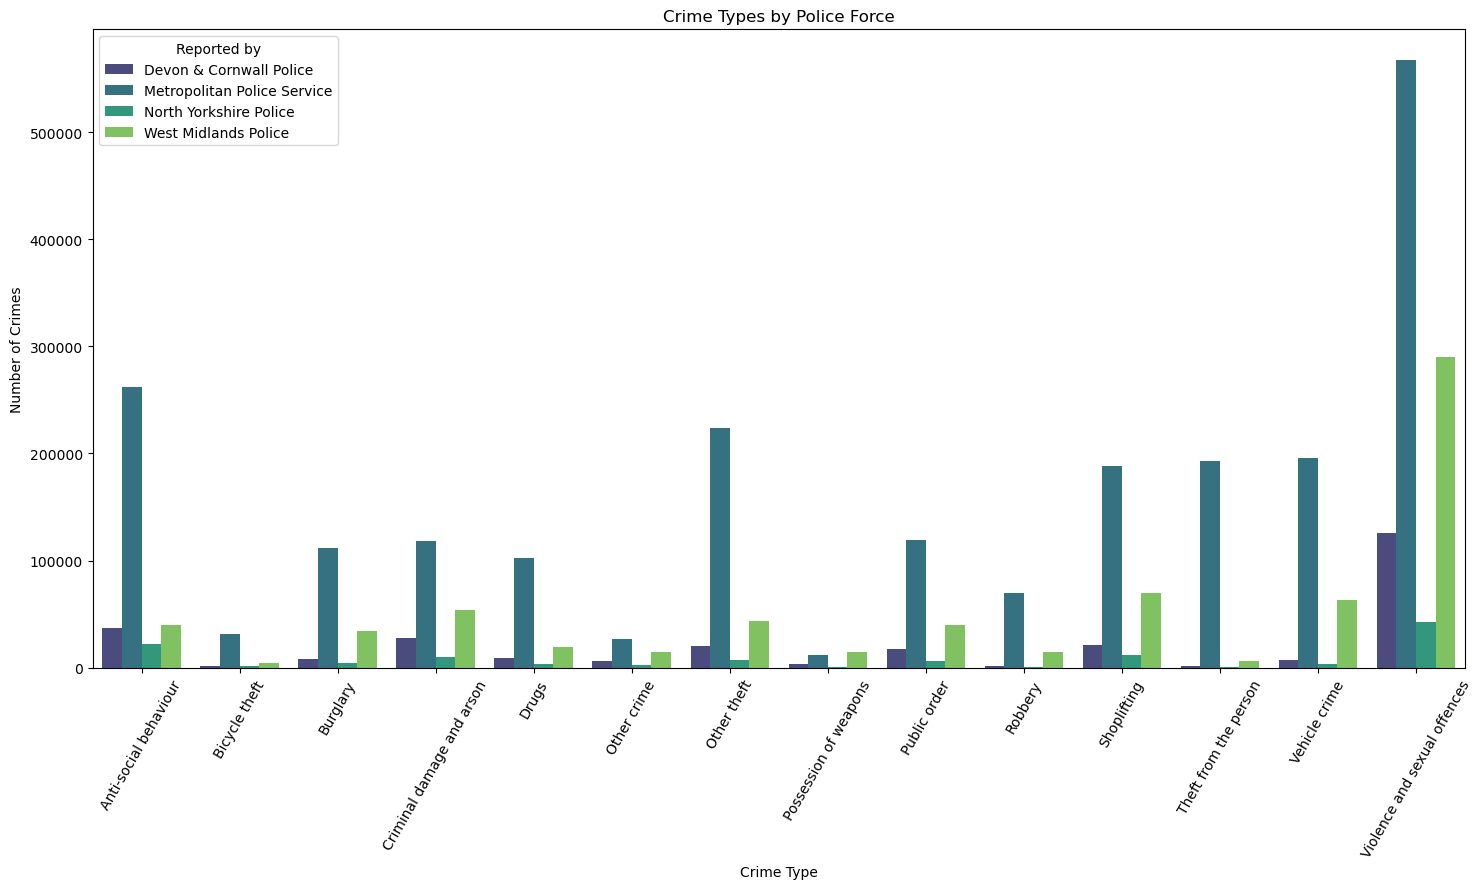

In [ ]:
# creating the bar chart

plt.figure(figsize=(15,9))  # so the smaller values don't look invisible

sns.barplot(data=crime_counts, x='Crime type', y='Crime_Count', hue='Reported by', palette = 'viridis')

# rotation so the axis is more clear
plt.xticks(rotation=60)
plt.title("Crime Types by Police Force")
plt.ylabel("Number of Crimes")
plt.xlabel("Crime Type")

plt.tight_layout()
plt.show()

In [ ]:
# heatmap but decided to just stick with bar charts
crime_counts = df.groupby(["Reported by","Crime type"]).size().unstack()

plt.figure(figsize=(9,6))

sns.heatmap(crime_counts, cmap="Reds", annot=False)

plt.title("Crime Distribution Across Police Forces")
plt.xlabel("Crime Type")
plt.ylabel("Police Force")

plt.show()

In [ ]:
# crime rate per 100k for reported by and population. 
lsoa_population = df[["Reported by","LSOA code","Population"]].drop_duplicates()
population_by_force = lsoa_population.groupby("Reported by")["Population"].sum()
crime_totals = df.groupby("Reported by").size()
comparison = pd.concat([crime_totals, population_by_force], axis=1)
comparison.columns = ["Total Crimes","Population"]

# crime rate per 100k
comparison["Crime Rate per 100k"] = ((comparison["Total Crimes"] / comparison["Population"]) * 100000)


comparison



,Total Crimes,Population,Crime Rate per 100k
Reported by,,,
Devon & Cornwall Police,288116,3431789,8395.504502
Metropolitan Police Service,2223054,18464908,12039.345119
North Yorkshire Police,118265,1057891,11179.318096
West Midlands Police,708277,3113162,22751.048612


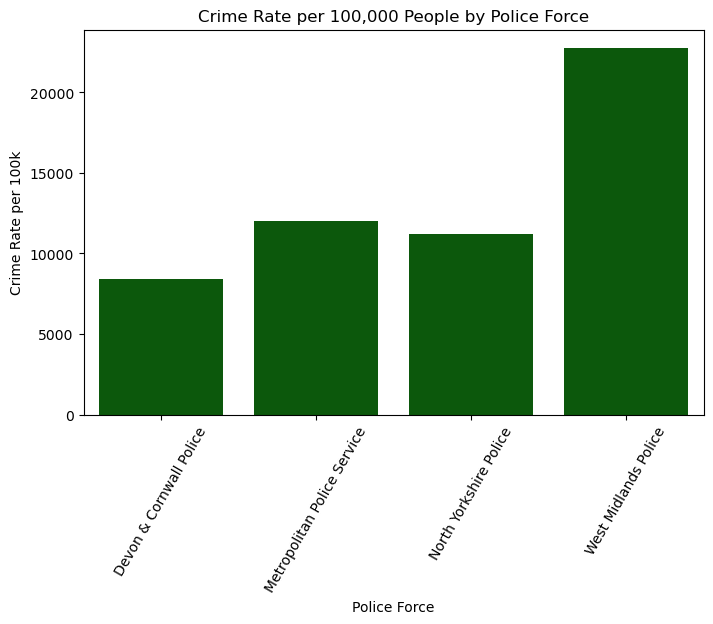

In [388]:
# bar chart of per 100k
plt.figure(figsize=(8,5))

sns.barplot(x=comparison.index, y=comparison['Crime Rate per 100k'], color = 'darkgreen')

plt.title("Crime Rate per 100,000 People by Police Force")
plt.xlabel("Police Force")
plt.ylabel("Crime Rate per 100k")

plt.xticks(rotation=60)

plt.show()

## Crime Trends over Time


In [ ]:
# year and total

average_year = df.groupby(["Year"]).size()
average_year

Year_crime
2024    1621717
2025    1598619
2026     117376
dtype: int64

In [ ]:
# year per months
average_month = df.groupby(["Year", "Month"]).size()
average_month

Year_crime  Month_crime
2024        April          130749
            August         140509
            December       130516
            February       123211
            January        125295
            July           145228
            June           138914
            March          132534
            May            139961
            November       137250
            October        141844
            September      135706
2025        April          133299
            August         137534
            December       123137
            February       121319
            January        125643
            July           147198
            June           140571
            March          134614
            May            140479
            November       129101
            October        135004
            September      130720
2026        January        117376
dtype: int64

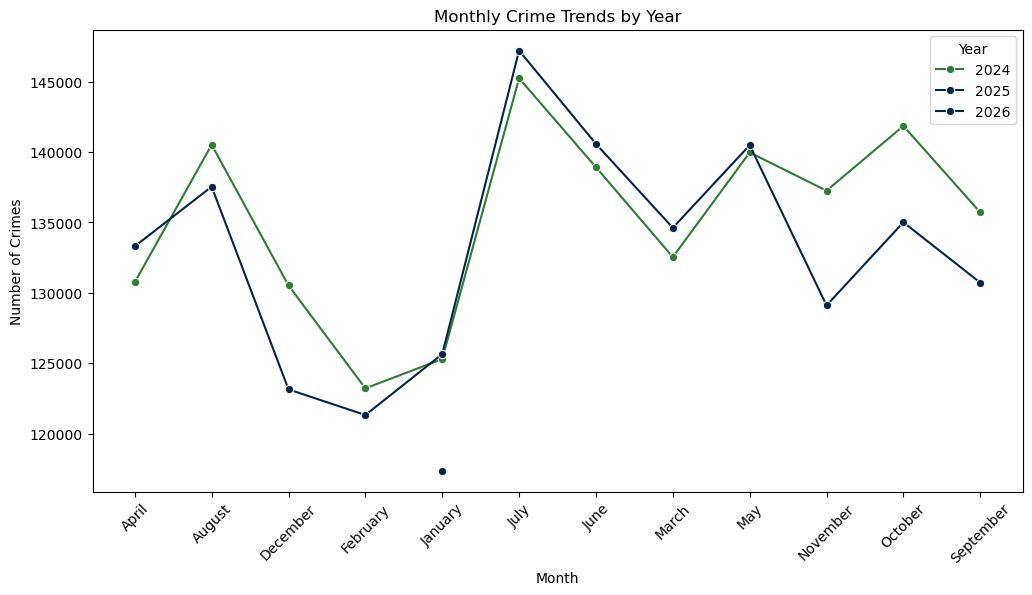

In [ ]:
colours = ['#2e7d32', "#04254b", "#04254b"] 
# line chart 
average_month = df.groupby(["Year", "Month"]).size().reset_index(name='Crime_Count')

plt.figure(figsize=(12,6))

sns.lineplot(data=average_month, x='Month', y='Crime_Count', hue='Year', marker = 'o', palette = colours)

plt.title("Monthly Crime Trends by Year")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=45)

plt.show()

In [ ]:
top5 = df['Crime type'].value_counts().head(5).index
df_top5 = df[df['Crime type'].isin(top5)]


typecrime = df_top5.groupby(["Crime type","Year"]).size()
typecrime


Crime type                    Year
Anti-social behaviour         2024    175965
                              2025    174945
                              2026     11257
Other theft                   2024    149639
                              2025    135733
                              2026     10049
Shoplifting                   2024    137004
                              2025    143953
                              2026      9886
Vehicle crime                 2024    139229
                              2025    121670
                              2026      9238
Violence and sexual offences  2024    486367
                              2025    500388
                              2026     39038
dtype: int64

C:\Users\sophi\AppData\Local\Temp\ipykernel_7108\4180718512.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_top5['Date'] = pd.to_datetime(df_top5['Year'].astype(str) + '-' + df_top5['Month'].astype(str))
C:\Users\sophi\AppData\Local\Temp\ipykernel_7108\4180718512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top5['Date'] = pd.to_datetime(df_top5['Year'].astype(str) + '-' + df_top5['Month'].astype(str))


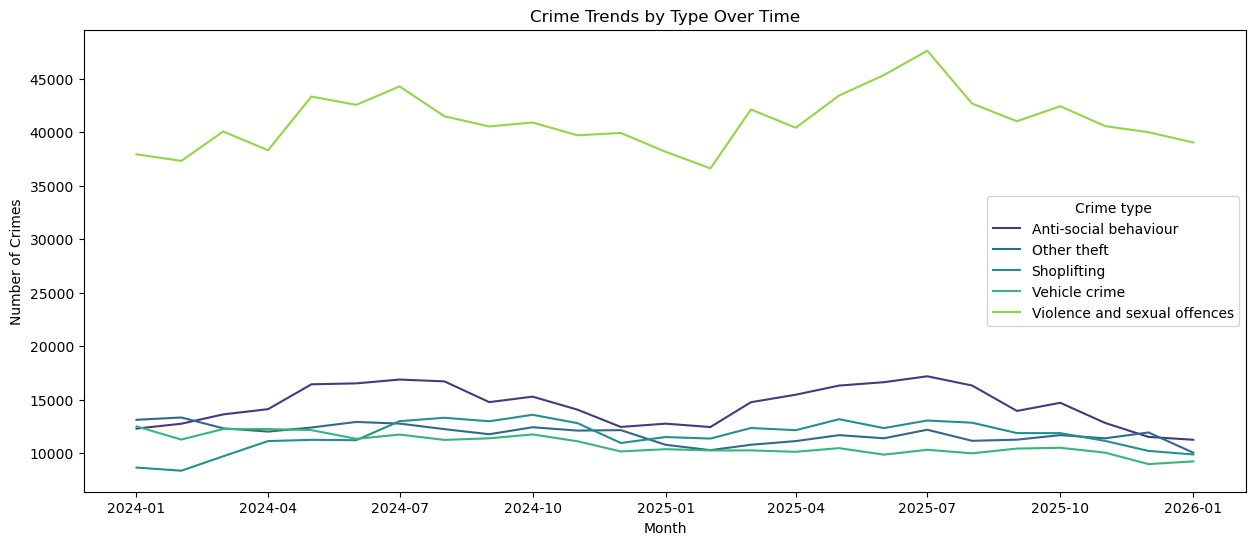

In [390]:
df_top5['Date'] = pd.to_datetime(df_top5['Year'].astype(str) + '-' + df_top5['Month'].astype(str))


crime_time = df_top5.groupby(['Date','Crime type']).size().reset_index(name='Crime_Count')
plt.figure(figsize=(15,6))

sns.lineplot(data=crime_time, x='Date', y='Crime_Count', hue='Crime type', palette = 'viridis')

plt.title("Crime Trends by Type Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")

plt.show()

In [260]:
typecrime = df.groupby(["Reported by","Year"]).size()
typecrime


Reported by                  Year
Devon & Cornwall Police      2024     137602
                             2025     140437
                             2026      10077
Metropolitan Police Service  2024    1071578
                             2025    1072326
                             2026      79150
North Yorkshire Police       2024      57793
                             2025      56544
                             2026       3928
West Midlands Police         2024     354744
                             2025     329312
                             2026      24221
dtype: int64

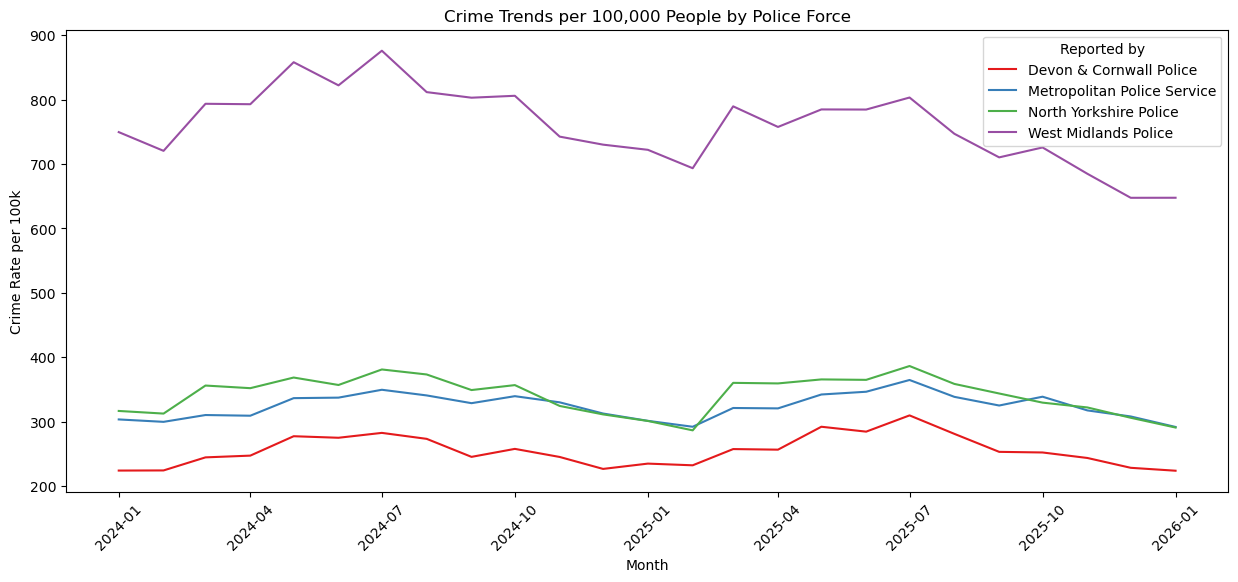

In [ ]:
# Calculate population per police force
lsoa_population = df[['Reported by','District','Population']].drop_duplicates()

population_force = lsoa_population.groupby('Reported by')['Population'].sum()

# Calculate crime counts over time
regioncrime = df_top5.groupby(["Date","Reported by"]).size().reset_index(name='Crime_Count')

# Add population to dataframe
regioncrime['Population'] = regioncrime['Reported by'].map(population_force)

# Convert to rate per 100k
regioncrime['Crime Rate per 100k'] = (regioncrime['Crime_Count'] / regioncrime['Population']) * 100000



# Plot line graph
plt.figure(figsize=(15,6))

sns.lineplot(data=regioncrime, x='Date', y='Crime Rate per 100k', hue='Reported by', palette='Set1')

plt.title("Crime Trends per 100,000 People by Police Force")
plt.xlabel("Month")
plt.ylabel("Crime Rate per 100k")

plt.xticks(rotation=45)

plt.show()

In [308]:
regioncrime

,Date,Reported by,Crime_Count,Population,Crime Rate per 100k
0,2024-01-01,Devon & Cornwall Police,7433,3314979,224.224648
1,2024-01-01,Metropolitan Police Service,53842,17734549,303.599488
2,2024-01-01,North Yorkshire Police,3261,1029478,316.762476
3,2024-01-01,West Midlands Police,19995,2667391,749.608887
4,2024-02-01,Devon & Cornwall Police,7440,3314979,224.435811
...,...,...,...,...,...
95,2025-12-01,West Midlands Police,17275,2667391,647.636586
96,2026-01-01,Devon & Cornwall Police,7425,3314979,223.983319
97,2026-01-01,Metropolitan Police Service,51770,17734549,291.916079
98,2026-01-01,North Yorkshire Police,2996,1029478,291.021275


## Crime outcome analysis


In [ ]:
df["Outcome type"].value_counts()

Outcome type
Investigation complete; no suspect identified          1376172
Unable to prosecute suspect                            1004232
Unknown                                                 627222
Suspect charged                                         196148
Local resolution                                         62837
Action to be taken by another organisation               24997
Offender given a caution                                 15138
Further investigation is not in the public interest      13145
Formal action is not in the public interest               8684
Offender given penalty notice                             5064
Further action is not in the public interest              3339
Suspect charged as part of another case                    544
Offender given a drugs possession warning                  190
Name: count, dtype: int64

In [ ]:
# Outcome type
df.groupby(["Reported by", "Outcome type"]).size()

Reported by_crime            Outcome type                                       
Devon & Cornwall Police      Action to be taken by another organisation                1900
                             Formal action is not in the public interest               4566
                             Further action is not in the public interest              2145
                             Further investigation is not in the public interest       7826
                             Investigation complete; no suspect identified            60843
                             Local resolution                                          4577
                             Offender given a caution                                  3146
                             Offender given a drugs possession warning                    9
                             Offender given penalty notice                                1
                             Suspect charged                                          15069

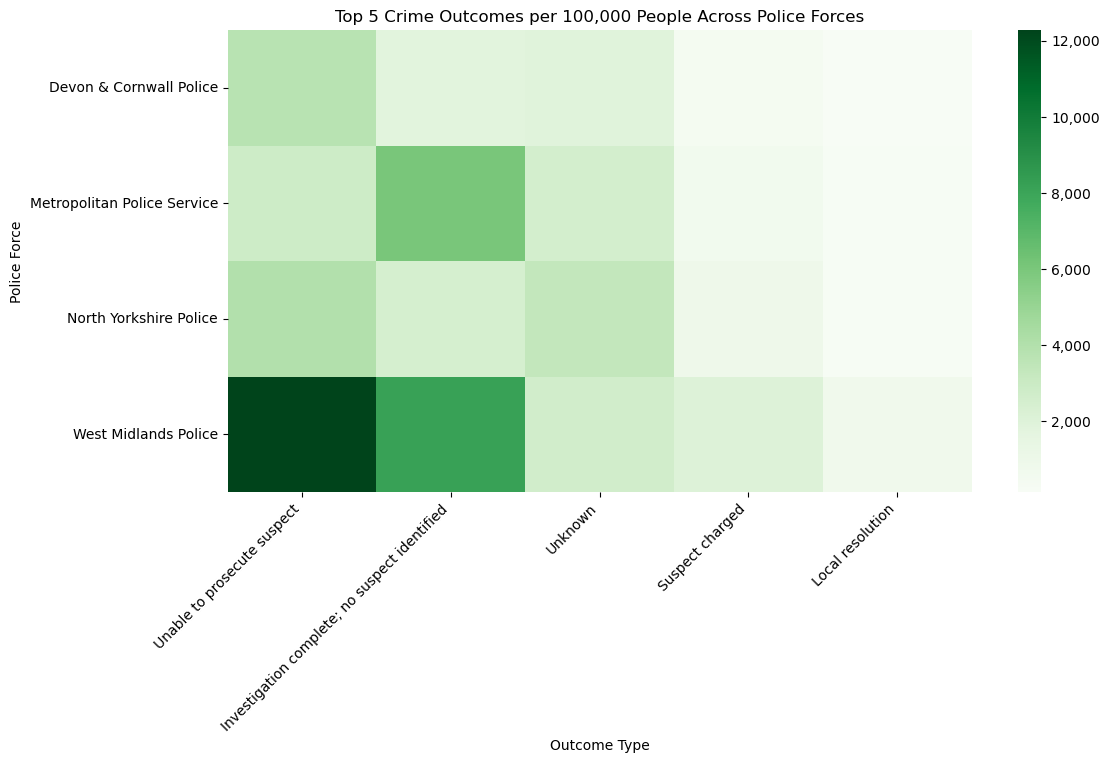

In [365]:
import matplotlib.ticker as ticker

# Calculate population per police force
lsoa_population = df[['Reported by','District','Population']].drop_duplicates()
population_force = lsoa_population.groupby('Reported by')['Population'].sum()

# Create outcome table
outcome_force = df.groupby(["Reported by","Outcome type"]).size().unstack(fill_value=0)

# Convert to rate per 100k
outcome_force_per100k = outcome_force.div(population_force, axis=0) * 100000

# Get top 5 outcomes overall
top5_outcomes = outcome_force_per100k.sum().sort_values(ascending=False).head(5).index

# Filter to top 5
outcome_top5 = outcome_force_per100k[top5_outcomes]

# Plot heatmap
plt.figure(figsize=(12,6))

ax = sns.heatmap(outcome_top5, cmap="Greens")

# Format colorbar numbers
cbar = ax.collections[0].colorbar
cbar.formatter = ticker.StrMethodFormatter('{x:,.0f}')
cbar.update_ticks()

plt.title("Top 5 Crime Outcomes per 100,000 People Across Police Forces")

plt.xlabel("Outcome Type")
plt.ylabel("Police Force")

plt.xticks(rotation=45, ha="right")

plt.show()

## Urban vs Rural Areas


In [303]:
# creating a column
df["Area type"] = df["Reported by"].replace({
    "Metropolitan Police Service": "Urban",
    "West Midlands Police": "Urban",
    "Devon & Cornwall Police": "Rural",
    "North Yorkshire Police": "Rural"
})


df["Area type"].unique()

array(['Rural', 'Urban'], dtype=object)

In [ ]:
crime_by_area = df.groupby(["Area_type","Crime type"]).size()

crime_by_area

Area_type  Crime type                  
Rural      Anti-social behaviour            59668
           Bicycle theft                     3169
           Burglary                         12451
           Criminal damage and arson        37677
           Drugs                            12245
           Other crime                       8804
           Other theft                      27455
           Possession of weapons             4376
           Public order                     24174
           Robbery                           1982
           Shoplifting                      33104
           Theft from the person             2234
           Vehicle crime                    10628
           Violence and sexual offences    168414
Urban      Anti-social behaviour           302499
           Bicycle theft                    35031
           Burglary                        145795
           Criminal damage and arson       172408
           Drugs                           121382
          

In [ ]:
# per 100k for urban and rural against crime rate
lsoa_population = df[["Area type","LSOA code","Population"]].drop_duplicates()

population_area = lsoa_population.groupby("Area type")["Population"].sum()

crime_area = df.groupby("Area type").size()

urban_rural = pd.concat([crime_area, population_area], axis=1)

urban_rural.columns = ["Total Crimes","Population"]

urban_rural['Crime Rate per 100k'] = (urban_rural["Total Crimes"] / urban_rural["Population"]) * 100000

urban_rural

,Total Crimes,Population,Crime Rate per 100k
Area type,,,
Rural,406381,4479054,9072.920309
Urban,2931331,20972992,13976.694408


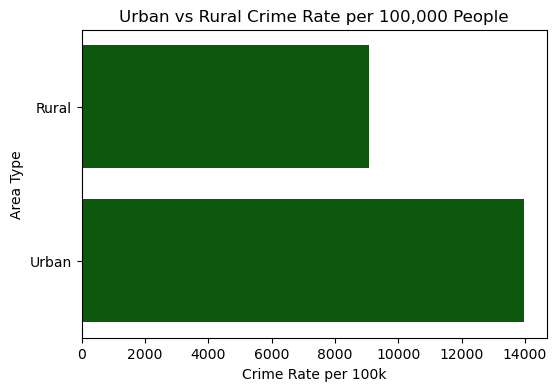

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(x=urban_rural["Crime Rate per 100k"], y=urban_rural.index, color = 'darkgreen')

plt.title("Urban vs Rural Crime Rate per 100,000 People")
plt.xlabel("Crime Rate per 100k")
plt.ylabel("Area Type")

plt.show()

In [ ]:
# crime type per 100k
crime_type_area = df.groupby(["Area type","Crime type"]).size().reset_index(name='Crime_Count')

crime_type_area["Population"] = crime_type_area["Area type"].map(population_area)

crime_type_area["Crime Rate per 100k"] = (crime_type_area["Crime_Count"] / crime_type_area["Population"]) * 100000

crime_type_area

,Area type,Crime type,Crime_Count,Population,Crime Rate per 100k
0,Rural,Anti-social behaviour,59668,4479054,1332.156299
1,Rural,Bicycle theft,3169,4479054,70.751547
2,Rural,Burglary,12451,4479054,277.982806
3,Rural,Criminal damage and arson,37677,4479054,841.182089
4,Rural,Drugs,12245,4479054,273.383621
5,Rural,Other crime,8804,4479054,196.559363
6,Rural,Other theft,27455,4479054,612.964255
7,Rural,Possession of weapons,4376,4479054,97.699202
8,Rural,Public order,24174,4479054,539.712180
9,Rural,Robbery,1982,4479054,44.250415


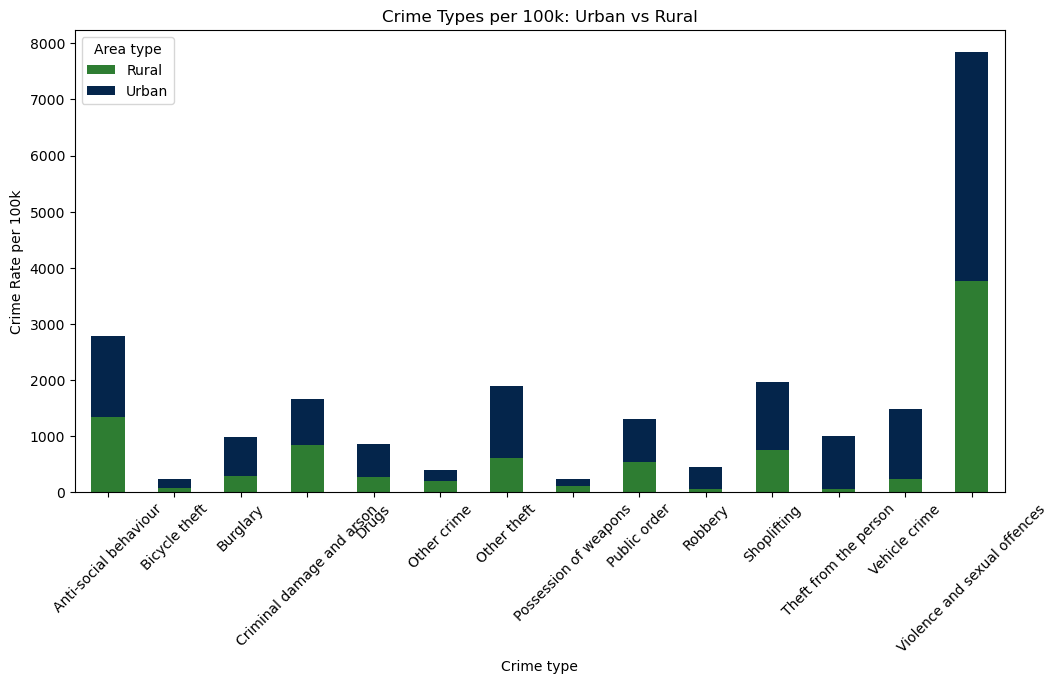

In [ ]:
colours = ['#2e7d32', "#04254b"] 

# Pivot data so area types become columns
pivot_df = crime_type_area.pivot(index='Crime type', columns='Area type', values='Crime Rate per 100k')

# Plot stacked bar chart
pivot_df.plot(kind='bar', stacked=True, figsize=(12,6), color = colours)

plt.xticks(rotation=45)
plt.title("Crime Types per 100k: Urban vs Rural")
plt.ylabel("Crime Rate per 100k")

plt.show()

## Crime map

In [ ]:
district_crime = df.groupby("District").size().reset_index(name='Crime_Count')
district_crime

,District_crime,Crime_Count
0,Adur,3
1,Allerdale,6
2,Amber Valley,6
3,Arun,26
4,Ashfield,11
...,...,...
326,Wrexham,12
327,Wychavon,18
328,Wyre,3
329,Wyre Forest,3


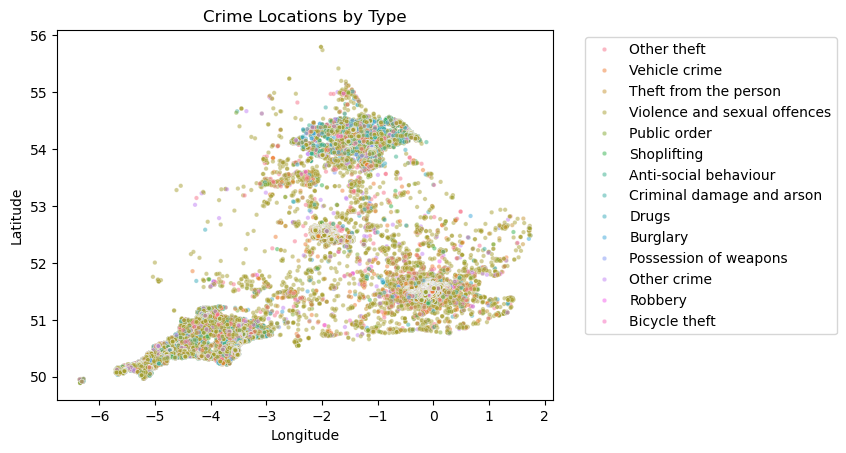

In [ ]:


sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='Crime type', alpha=0.5, s = 10)

plt.title("Crime Locations by Type")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()